# 📋 Bahrain Bites Analyzer — Pretrained Model Challenge



## 1. Load the data

In [1]:
import pandas as pd
import re

df_sent = pd.read_csv("reviews_sentiment.csv")
df_topic = pd.read_csv("reviews_topics.csv")

assert (df_sent['text'] == df_topic['text']).all()

df_sent['language'] = df_sent['text'].apply(lambda t: 'ar' if re.search(r'[\u0600-\u06FF]', t) else 'en')
df_topic['language'] = df_topic['text']. apply(lambda t: 'ar' if re.search(r'[\u0600-\u06FF]', t) else 'en')

print(f"{len(df_sent)} reviews ({(df_sent.language=='en').sum()} English, {(df_sent.language=='ar').sum()} Arabic)")
df_sent.head()


60 reviews (34 English, 26 Arabic)


,id,text,label,language
0,1,"The shawarma here is amazing, best I've had in...",positive,en
1,2,مطعم زين بس الخدمة شوي بطيئة,neutral,ar
2,3,"Service was painfully slow, we waited 40 minut...",negative,en
3,4,الأكل خوش بس الأسعار وايد غالية,negative,ar
4,5,"Decent food, nothing special but not bad either.",neutral,en


## 2. Sentiment models

Three models, chosen to test language/dialect coverage:

| Model | Trained on |
|---|---|
| `cardiffnlp/twitter-roberta-base-sentiment-latest` | English tweets |
| `CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment` | Dialectal Arabic |
| `nlptown/bert-base-multilingual-uncased-sentiment` | Multilingual product reviews |


In [2]:
from transformers import pipeline

MODELS = {
    "CardiffNLP (EN)": "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "CAMeLBERT-DA (AR)": "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment",
    "NLPTown (Multilingual)": "nlptown/bert-base-multilingual-uncased-sentiment",
}

pipelines = {name: pipeline("sentiment-analysis", model=model_id) for name, model_id in MODELS.items()}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 3. Run inference


In [4]:
def map_label(model_name, raw_label):
    if model_name == "NLPTown (Multilingual)":
        stars = int(raw_label[0])
        return "negative" if stars <= 2 else "neutral" if stars == 3 else "positive"
    return raw_label.lower()

def run_model(name, pipe, df):
    rows = []
    for _, row in df.iterrows():
        raw = pipe(row['text'])[0]
        rows.append({
            "id": row['id'], "text": row['text'], "language": row['language'],
            "true_label": row['label'],
            "label": raw["label"], "score": float(raw["score"]),
            "mapped_label": map_label(name, raw["label"]),
        })
    return pd.DataFrame(rows)

results = {name: run_model(name, pipe, df_sent) for name, pipe in pipelines.items()}
results["CardiffNLP (EN)"].head()


,id,text,language,true_label,label,score,mapped_label
0,1,"The shawarma here is amazing, best I've had in...",en,positive,positive,0.985027,positive
1,2,مطعم زين بس الخدمة شوي بطيئة,ar,neutral,neutral,0.650974,neutral
2,3,"Service was painfully slow, we waited 40 minut...",en,negative,negative,0.944747,negative
3,4,الأكل خوش بس الأسعار وايد غالية,ar,negative,neutral,0.682494,neutral
4,5,"Decent food, nothing special but not bad either.",en,neutral,positive,0.829798,positive


## 4. Evaluate

In [5]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

summary = []
for name, res in results.items():
    acc = accuracy_score(res['true_label'], res['mapped_label'])
    f1 = f1_score(res['true_label'], res['mapped_label'], average='macro')
    acc_en = accuracy_score(res[res.language=='en']['true_label'], res[res.language=='en']['mapped_label'])
    acc_ar = accuracy_score(res[res.language=='ar']['true_label'], res[res.language=='ar']['mapped_label'])
    summary.append({"model": name, "accuracy": acc, "macro_f1": f1, "acc_english": acc_en, "acc_arabic": acc_ar})

summary_df = pd.DataFrame(summary)
summary_df


,model,accuracy,macro_f1,acc_english,acc_arabic
0,CardiffNLP (EN),0.500000,0.500285,0.735294,0.192308
1,CAMeLBERT-DA (AR),0.366667,0.372975,0.205882,0.576923
2,NLPTown (Multilingual),0.716667,0.677293,0.794118,0.615385


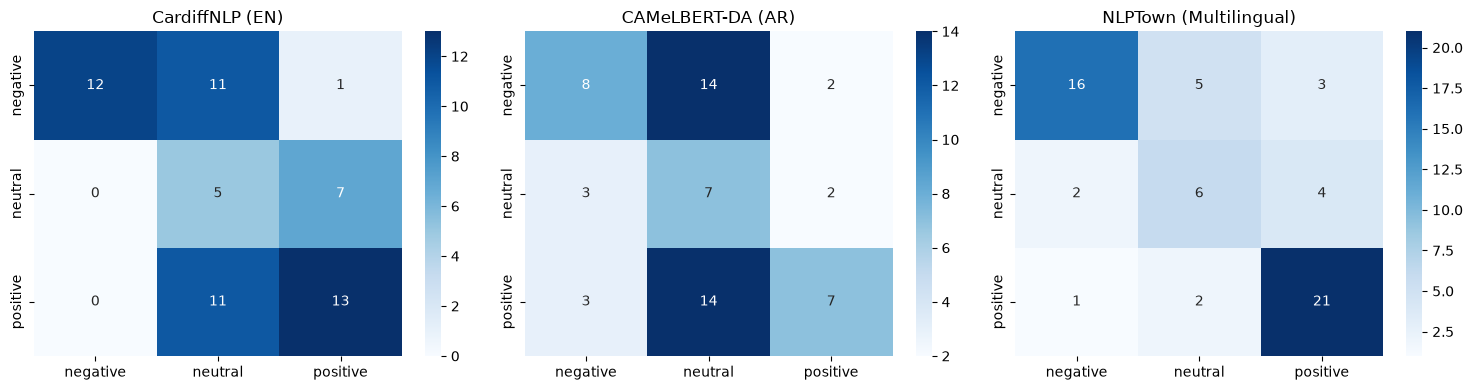

In [6]:
labels_order = ["negative", "neutral", "positive"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['true_label'], res['mapped_label'], labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_order, yticklabels=labels_order, ax=ax, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 5. Error analysis


In [7]:
best_model = summary_df.sort_values('accuracy', ascending=False).iloc[0]['model']
errors = results[best_model]
errors = errors[errors['true_label'] != errors['mapped_label']]
errors[['text', 'language', 'true_label', 'mapped_label', 'score']].head(10)


,text,language,true_label,mapped_label,score
1,مطعم زين بس الخدمة شوي بطيئة,ar,neutral,positive,0.371832
7,صراحة ما عيبني، الطعم مب زين والخدمة بطيئة وايد,ar,negative,positive,0.558045
14,"Nice view of the sea from the rooftop, food wa...",en,neutral,positive,0.522384
15,الحچي الحلو مب چذي، الأكل بارد والطلب متأخر وايد,ar,negative,neutral,0.246401
17,تجربة عادية بس، مب شي يستاهل نرجع له مرة ثانية,ar,neutral,negative,0.435961
18,"The biryani was too spicy for my taste, but my...",en,neutral,positive,0.415453
21,الشاورما هني أحلى شي جربته، رخيصة ومية المية,ar,positive,negative,0.525310
25,الجلسة الخارجية حلوة بس الذباب كثير وايد,ar,negative,positive,0.330855
26,"It was fine. Nothing that stood out, nothing t...",en,neutral,positive,0.460479
27,الحلا كان تحفة، خصوصا أم علي,ar,positive,neutral,0.255874


## 6. Zero-shot topic classification

In [ ]:
topic_clf = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7")

TOPICS = ["Food Quality", "Service", "Price", "Cleanliness", "Atmosphere", "Location", "Waiting Time"]

topic_rows = []
for _, row in df_topic.iterrows():
    raw = topic_clf(row['text'], TOPICS)
    topic_rows.append({
        "id": row['id'], "text": row['text'], "language": row['language'],
        "true_label": row['label'], "label": raw["labels"][0], "score": float(raw["scores"][0]),
        "metadata": "huggingface_AI_model",
    })

topic_results = pd.DataFrame(topic_rows)
topic_acc = accuracy_score(topic_results['true_label'], topic_results['label'])
topic_f1 = f1_score(topic_results['true_label'], topic_results['label'], average='macro')
print(f"Topic accuracy: {topic_acc:.3f}   Macro F1: {topic_f1:.3f}")
topic_results.head()


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [ ]:
topic_errors = topic_results[topic_results['true_label'] != topic_results['label']]
topic_errors[['text', 'language', 'true_label', 'label', 'score']]
